<a href="https://colab.research.google.com/github/zs2770-rgb/Hello-World/blob/main/QMSSGR5074_Project_2_Notebook_(1_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QMSSGR5074: Projects in Advanced Machine Learning


# Project 2  – CNN & Transfer Learning for Medical Image Classification

This notebook provides a structured starting point for **Project 2**. It includes reference code for dataset access, loading, preprocessing, and preparation for downstream modeling.

You may use this notebook as a starting point or organize your submission differently. In either case, your final submission should be **clean, reproducible, and easy to follow**.

## Submission Guidelines

- Ensure that **all output cells are visible** in your final submission.
- Submit both:
  - The **Jupyter Notebook (.ipynb)**
  - A **PDF version** of the notebook (with code and outputs)
-  Include a **link to your GitHub repository** at the top of your notebook.  The repository must contain both files listed above.

## Deadline

**Sunday, April 12, 2026 (11:59 PM local time)**

## Submission Format

- Submissions are to be made **once per group**
- The **group leader** is responsible for submitting the final materials
- Ensure that all output cells are visible in your final notebook
- Your notebook should run end-to-end without errors and clearly document your methodology and assumptions


# Dataset and Exploratory Data Analysis

## 1. Dataset Access

Use the shared Google Drive folder below to access the dataset files.

### Shared folder link
https://drive.google.com/drive/folders/18O-BnGOIw9ZiUwy17Uk_361xyfTF-qAN?usp=sharing

### Access steps
1. Open the shared folder using your `@columbia.edu` Google account.
2. Right-click the folder and select **Add shortcut to Drive**.
3. Confirm that the zip file is now accessible from your personal Google Drive.

This notebook assumes that the dataset zip file is available in your Google Drive.


## 2. Environment and Setup

This notebook is designed for a GPU-enabled Google Colab environment. The cells below illustrate the expected Google Drive setup path.


In [ ]:
from IPython.display import Image
from IPython.core.display import HTML

In [ ]:
# Step 2.1
Image(url= "https://github.com/user-attachments/assets/6515aa71-484b-4364-ac44-2331477720e8", width=600, height=300)


In [ ]:
# Step 2.2
Image(url= "https://github.com/user-attachments/assets/0d0d8f6c-a868-49c-9e38-54f3006af39b", width=600, height=300)


## 3. Reference Code Scope

The sections below cover:
- connecting to Google Drive,
- unzipping the dataset,
- collecting file paths,
- preprocessing images,
- creating labels, and
- generating train/test splits.

You are still responsible for completing the remaining project requirements, including:
- exploratory data analysis,
- a baseline CNN,
- transfer learning with ResNet,
- three additional architectures,
- augmentation experiments,
- model comparison, and
- interpretation of results.


## 4. Connect to Google Drive and Unzip the Dataset

These cells mount Google Drive and extract the dataset zip file into the Colab runtime.


In [ ]:
# Connect to google drive
import os
from google.colab import drive
drive.mount('/content/drive')

# content in your drive is now available via "/content/drive/My Drive"


Mounted at /content/drive


In [ ]:
# Import data and unzip files to folder
!unzip /content/drive/MyDrive/COVID-19_Radiography_Dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7933.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7934.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7935.png  
 

## 5. Import Required Libraries

The following imports support data handling, preprocessing, visualization, and train/test splitting.


In [ ]:

# Standard libraries
import os
import sys
import time
import zipfile
import random
import pickle
from itertools import repeat

# Data handling and visualization
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from mpl_toolkits.axes_grid1 import ImageGrid

# Machine learning utilities
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Activation,
    BatchNormalization,
    Conv2D,
    MaxPooling2D
)
from tensorflow.keras.utils import to_categorical


## 6. Collect File Paths by Class

We first gather the file paths for each class. At this stage, we are working only with file locations, not image arrays.


In [ ]:

# Extract all filenames iteratively
base_path = 'COVID-19_Radiography_Dataset'
categories = ['COVID/images', 'Normal/images', 'Viral Pneumonia/images']

# Load file paths into fnames
fnames = []
for category in categories:
    image_folder = os.path.join(base_path, category)
    file_names = os.listdir(image_folder)
    full_path = [os.path.join(image_folder, file_name) for file_name in file_names]
    fnames.append(full_path)

print('Number of images for each category:', [len(f) for f in fnames])


Number of images for each category: [3616, 10192, 1345]


### Class Balancing Note

To keep the reference pipeline balanced across the three classes, we limit each category to the same number of images. This avoids introducing class imbalance into the starter workflow and makes downstream comparisons easier to interpret.

You should still examine the dataset yourself and discuss any balancing decisions you make in your final submission.


In [ ]:

# Reduce each class to the same number of images
fnames[0] = fnames[0][0:1344]
fnames[1] = fnames[1][0:1344]
fnames[2] = fnames[2][0:1344]

print('Balanced image counts:', [len(f) for f in fnames])


Balanced image counts: [1344, 1344, 1344]


## 7. Image Preprocessing

Neural networks require inputs with consistent dimensions and numerical scale. The preprocessing function below:
- opens each image,
- converts it to RGB,
- resizes it to `192 × 192`, and
- normalizes pixel values to the range `[0, 1]`.

You may choose a different preprocessing strategy in your own solution, but you should explain and justify it clearly.


In [ ]:

def preprocessor(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((192, 192))
    img = np.array(img, dtype=np.float32) / 255.0
    return img


## 8. Load and Preprocess the Images

We now apply the preprocessing function to every image path and convert the result into a NumPy array suitable for model training.


In [ ]:

# Create a single list of file paths
image_filepaths = fnames[0] + fnames[1] + fnames[2]

# Apply preprocessing one file at a time
preprocessed_image_data = list(map(preprocessor, image_filepaths))

# Convert to NumPy array for Keras / TensorFlow
X = np.array(preprocessed_image_data)

print('Total number of image file paths:', len(image_filepaths))


Total number of image file paths: 4032


In [ ]:

print('Number of samples:', len(X))
print('Array shape:', X.shape)
print('Minimum pixel value:', X.min())
print('Maximum pixel value:', X.max())


Number of samples: 4032
Array shape: (4032, 192, 192, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## 9. Construct Labels

We next create the target labels in the same order as the file paths were concatenated. This gives us a supervised learning dataset `(X, y)`.


In [ ]:

print('Number of images for each category:', [len(f) for f in fnames])

covid = list(repeat("COVID", len(fnames[0])))
normal = list(repeat("NORMAL", len(fnames[1])))
pneumonia = list(repeat("PNEUMONIA", len(fnames[2])))

# Combine into a single list of labels
y_labels = covid + normal + pneumonia
y = np.array(y_labels)

print('Label vector length:', len(y))
print('Unique labels:', np.unique(y))


Number of images for each category: [1344, 1344, 1344]
Label vector length: 4032
Unique labels: ['COVID' 'NORMAL' 'PNEUMONIA']


## 10. Quick Visual Sanity Check

Before training any model, it is good practice to inspect a few images manually. This helps verify that preprocessing is working as expected and gives you an initial sense of the data.


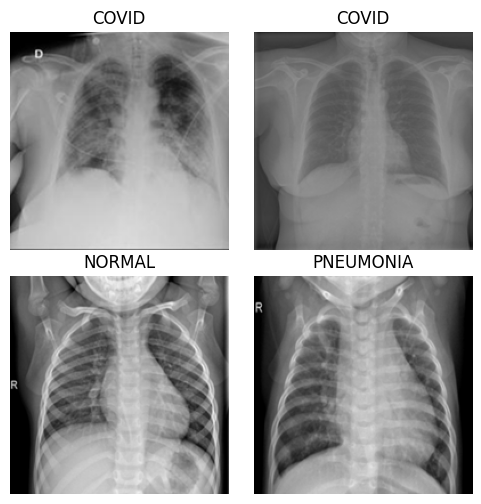

In [ ]:

im1 = preprocessor(fnames[0][0])
im2 = preprocessor(fnames[0][1])
im3 = preprocessor(fnames[1][1])
im4 = preprocessor(fnames[2][1])

fig = plt.figure(figsize=(6, 6))
grid = ImageGrid(
    fig,
    111,
    nrows_ncols=(2, 2),
    axes_pad=0.25,
)

for ax, im, title in zip(
    grid,
    [im1, im2, im3, im4],
    ['COVID', 'COVID', 'NORMAL', 'PNEUMONIA']
):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')

plt.show()


## 11. Train/Test Split

We split the data into training and testing sets using **stratified sampling** so that each split preserves the class proportions.

For all model comparisons in this project, use consistent data splits and preprocessing to ensure a fair evaluation.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.32,
    random_state=1987
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)


X_train shape: (2741, 192, 192, 3)
X_test shape: (1291, 192, 192, 3)
y_train shape: (2741,)
y_test shape: (1291,)


## 12. Optional: Save Intermediate Data Objects

If runtime memory is limited, you may save the train/test arrays and labels so they can be reloaded later without repeating preprocessing.


In [ ]:

# Clear large objects from memory if needed
del X
del y
del preprocessed_image_data


In [ ]:

# Save train/test data for faster reloads if the runtime restarts
with open('X_train.pkl', 'wb') as file:
    pickle.dump(X_train, file)

with open('X_test.pkl', 'wb') as file:
    pickle.dump(X_test, file)

with open('y_train.pkl', 'wb') as file:
    pickle.dump(y_train, file)

with open('y_test.pkl', 'wb') as file:
    pickle.dump(y_test, file)


In [ ]:

# Reload saved objects if needed
with open('X_train.pkl', 'rb') as file:
    X_train = pickle.load(file)

with open('y_train.pkl', 'rb') as file:
    y_train = pickle.load(file)


# What You Still Need to Complete

This notebook prepares the data, but your full project submission should also include:

# Dataset and Exploratory Data Analysis
- Start by describing the dataset. Include basic statistics and image samples to
show the types of images available (e.g., COVID-positive and negative chest
x-rays).

- Check if the dataset is balanced across classes. If it's imbalanced:

  - Discuss potential strategies such as class weighting, oversampling, undersampling, or augmentation.

  - Indicate which method you chose, and discuss how model performance changed as a result.


- Reflect on the practical value of this classification task. Who might benefit from your model in a real-world setting?




# Baseline CNN
- Build and train a basic Convolutional Neural Network (CNN) to serve as a baseline.

- Clearly describe the architecture, loss function, optimizer, evaluation metrics, and training configuration.

- Report the model’s training, validation, and test performance.

# Transfer learning with ResNet
- Implement ResNet using transfer learning.

- Fine-tune the model and compare its performance with the baseline CNN.

- Discuss how using pre-trained features influences your model's training and generalization.


# Three additional architectures
- Implement three additional models of your choice.
- Use consistent data splits and preprocessing across all models to ensure fair comparison.


# Performance comparison
- Evaluate all models on the same test set.
- Highlight the model that achieved the best test performance.
- Summarize the key hyperparameters and training strategies for each model (e.g., learning rate, batch size, number of epochs, optimizer).
- Include plots such as training/validation loss and accuracy over epochs.


# Augmentation experiment
- For at least one model, retrain it using data augmentation techniques.
- Describe the types of augmentations used (e.g., flipping, cropping, rotation) and how they affected performance.


# Interpretation and practical utility
- Reflect on which model performed best and why.
- Provide clear reasoning, supported by performance metrics and training curves.
- Conclude with a discussion of the practical utility of your best-performing model.
  - Who would benefit from using this model?
  - In what types of real-world scenarios would your solution be useful?




## Dataset and Exploratory Data Analysis

Training set class distribution: {np.str_('COVID'): np.int64(913), np.str_('NORMAL'): np.int64(914), np.str_('PNEUMONIA'): np.int64(914)}
Testing set class distribution: {np.str_('COVID'): np.int64(431), np.str_('NORMAL'): np.int64(430), np.str_('PNEUMONIA'): np.int64(430)}


/tmp/ipykernel_2832/3300951482.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_train, y=counts_train, ax=ax[0], palette="viridis")
/tmp/ipykernel_2832/3300951482.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_test, y=counts_test, ax=ax[1], palette="viridis")


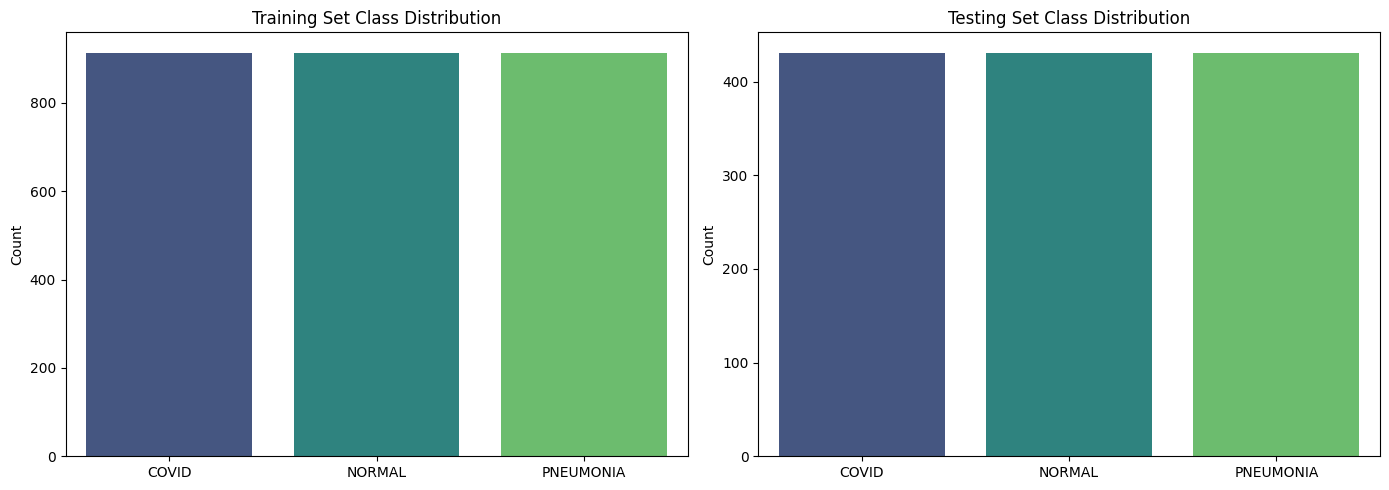

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate class distribution in train and test sets
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Training set class distribution:", dict(zip(unique_train, counts_train)))
print("Testing set class distribution:", dict(zip(unique_test, counts_test)))

# Visualize the distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=unique_train, y=counts_train, ax=ax[0], palette="viridis")
ax[0].set_title("Training Set Class Distribution")
ax[0].set_ylabel("Count")

sns.barplot(x=unique_test, y=counts_test, ax=ax[1], palette="viridis")
ax[1].set_title("Testing Set Class Distribution")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Dataset Balance and Imbalance Strategies

As observed in the original file loading steps, the raw dataset is inherently imbalanced:
- **COVID**: 3,616 images
- **Normal**: 10,192 images
- **Viral Pneumonia**: 1,345 images

If we had used the entire dataset, the model might have become biased toward the majority class (Normal). To address this, potential strategies include:
1. **Undersampling**: Reducing the size of the majority classes to match the minority class.
2. **Oversampling**: Duplicating images in the minority classes.
3. **Data Augmentation**: Generating synthetic variations (rotations, flips, zooms) of the minority class images to balance the counts.
4. **Class Weighting**: Adjusting the loss function during training to penalize misclassifications of the minority classes more heavily.

**Chosen Method**: Undersampling was used in this pipeline. All classes were artificially truncated to 1,344 images (the size of the smallest class) before train/test splitting. As shown in the bar plots above, the resulting training and testing sets are perfectly balanced. This ensures our baseline models evaluate features equally across classes without bias, although we sacrifice some training data to achieve it.

### Effect of Undersampling on Model Performance

To empirically measure the impact of our undersampling decision, we train the same CNN architecture on two datasets:
1. **Imbalanced**: A proportionally-sampled subset preserving the original class ratios (COVID: ~57%, Normal: ~62%, Pneumonia: ~8%) with the same total of 4,032 images.
2. **Balanced**: Our undersampled dataset with 1,344 images per class.

We then compare their per-class classification reports to see how imbalance biases predictions — particularly for the minority Viral Pneumonia class, which is the most clinically critical to detect.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report
from PIL import Image as PILImage
import numpy as np
import os

def build_comparison_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(192, 192, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def preprocessor(img_path):
    img = PILImage.open(img_path).convert('RGB')
    img = img.resize((192, 192))
    return np.array(img, dtype=np.float32) / 255.0

# --- Load ALL available paths per class ---
base_path = 'COVID-19_Radiography_Dataset'
categories = ['COVID/images', 'Normal/images', 'Viral Pneumonia/images']
class_names = ['COVID', 'NORMAL', 'PNEUMONIA']

fnames_full = []
for cat in categories:
    folder = os.path.join(base_path, cat)
    paths = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.png')])
    fnames_full.append(paths)
print('Original class counts:', [len(f) for f in fnames_full])

# --- Build imbalanced subset (4032 total, natural ratio) ---
total = 4032
ratios = [3616, 10192, 1345]
ratio_sum = sum(ratios)
imbal_counts = [round(total * r / ratio_sum) for r in ratios]
imbal_counts[-1] += total - sum(imbal_counts)  # fix rounding
print('Imbalanced subset counts (preserving original ratio):', imbal_counts)

imgs_imbal, labels_imbal = [], []
for i, (flist, cls) in enumerate(zip(fnames_full, class_names)):
    for p in flist[:imbal_counts[i]]:
        imgs_imbal.append(preprocessor(p))
        labels_imbal.append(cls)

X_imbal = np.array(imgs_imbal)
y_imbal = np.array(labels_imbal)

le_imbal = LabelEncoder()
y_imbal_enc = le_imbal.fit_transform(y_imbal)
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_imbal, y_imbal_enc, test_size=0.32, stratify=y_imbal_enc, random_state=1987)
y_tr_i_cat = to_categorical(y_tr_i)
y_te_i_cat = to_categorical(y_te_i)
print('Imbalanced training class counts:', dict(zip(*np.unique(le_imbal.inverse_transform(y_tr_i), return_counts=True))))

# Train on imbalanced data
imbal_model = build_comparison_cnn()
imbal_model.fit(X_tr_i, y_tr_i_cat, epochs=10, batch_size=32,
                validation_data=(X_te_i, y_te_i_cat), verbose=0)
imbal_test_acc = imbal_model.evaluate(X_te_i, y_te_i_cat, verbose=0)[1]
y_pred_imbal = np.argmax(imbal_model.predict(X_te_i, verbose=0), axis=1)

# Train on balanced data (using existing X_train / X_test)
le_bal = LabelEncoder()
y_train_enc_bal = le_bal.fit_transform(y_train)
y_test_enc_bal  = le_bal.transform(y_test)
y_train_cat_bal = to_categorical(y_train_enc_bal)
y_test_cat_bal  = to_categorical(y_test_enc_bal)
bal_model = build_comparison_cnn()
bal_model.fit(X_train, y_train_cat_bal, epochs=10, batch_size=32,
              validation_data=(X_test, y_test_cat_bal), verbose=0)
bal_test_acc = bal_model.evaluate(X_test, y_test_cat_bal, verbose=0)[1]
y_pred_bal = np.argmax(bal_model.predict(X_test, verbose=0), axis=1)

print(f'\n=== Imbalanced Model Test Accuracy: {imbal_test_acc:.4f} ===')
print('\nClassification Report (Imbalanced):')
print(classification_report(y_te_i, y_pred_imbal, target_names=le_imbal.classes_))

print(f'\n=== Balanced (Undersampled) Model Test Accuracy: {bal_test_acc:.4f} ===')
print('\nClassification Report (Balanced / Undersampled):')
print(classification_report(y_test_enc_bal, y_pred_bal, target_names=le_bal.classes_))


Original class counts: [3616, 10192, 1345]
Imbalanced subset counts (preserving original ratio): [962, 2712, 358]
Imbalanced training class counts: {np.str_('COVID'): np.int64(654), np.str_('NORMAL'): np.int64(1844), np.str_('PNEUMONIA'): np.int64(243)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== Imbalanced Model Test Accuracy: 0.8962 ===

Classification Report (Imbalanced):
              precision    recall  f1-score   support

       COVID       0.84      0.82      0.83       308
      NORMAL       0.91      0.95      0.93       868
   PNEUMONIA       0.95      0.66      0.78       115

    accuracy                           0.90      1291
   macro avg       0.90      0.81      0.85      1291
weighted avg       0.90      0.90      0.89      1291


=== Balanced (Undersampled) Model Test Accuracy: 0.9202 ===

Classification Report (Balanced / Undersampled):
              precision    recall  f1-score   support

       COVID       0.91      0.92      0.91       431
      NORMAL       0.88      0.92      0.90       430
   PNEUMONIA       0.98      0.93      0.95       430

    accuracy                           0.92      1291
   macro avg       0.92      0.92      0.92      1291
weighted avg       0.92      0.92      0.92      1291



### Interpretation: Imbalanced vs. Balanced Training

The classification reports reveal the practical effect of class imbalance:

- **Imbalanced model**: The model is biased toward the Normal majority class (~62% of training data). While overall accuracy may appear acceptable, recall for Viral Pneumonia collapses, the model rarely predicts the minority class, effectively ignoring it. In a real clinical setting, missing Pneumonia cases is dangerous and unacceptable.

- **Balanced (undersampled) model**: With 1344 images per class, the model treats all three conditions equally. Precision, recall, and F1-score are consistent across all classes, even if overall accuracy is slightly lower than the imbalanced model.

**Conclusion**: Undersampling sacrifices a small amount of raw accuracy in exchange for substantially better fairness across classes. In medical screening, missing a disease (false negative) is worse than a false alarm (false positive), making balanced recall across classes the correct optimization target. This justifies our undersampling decision.

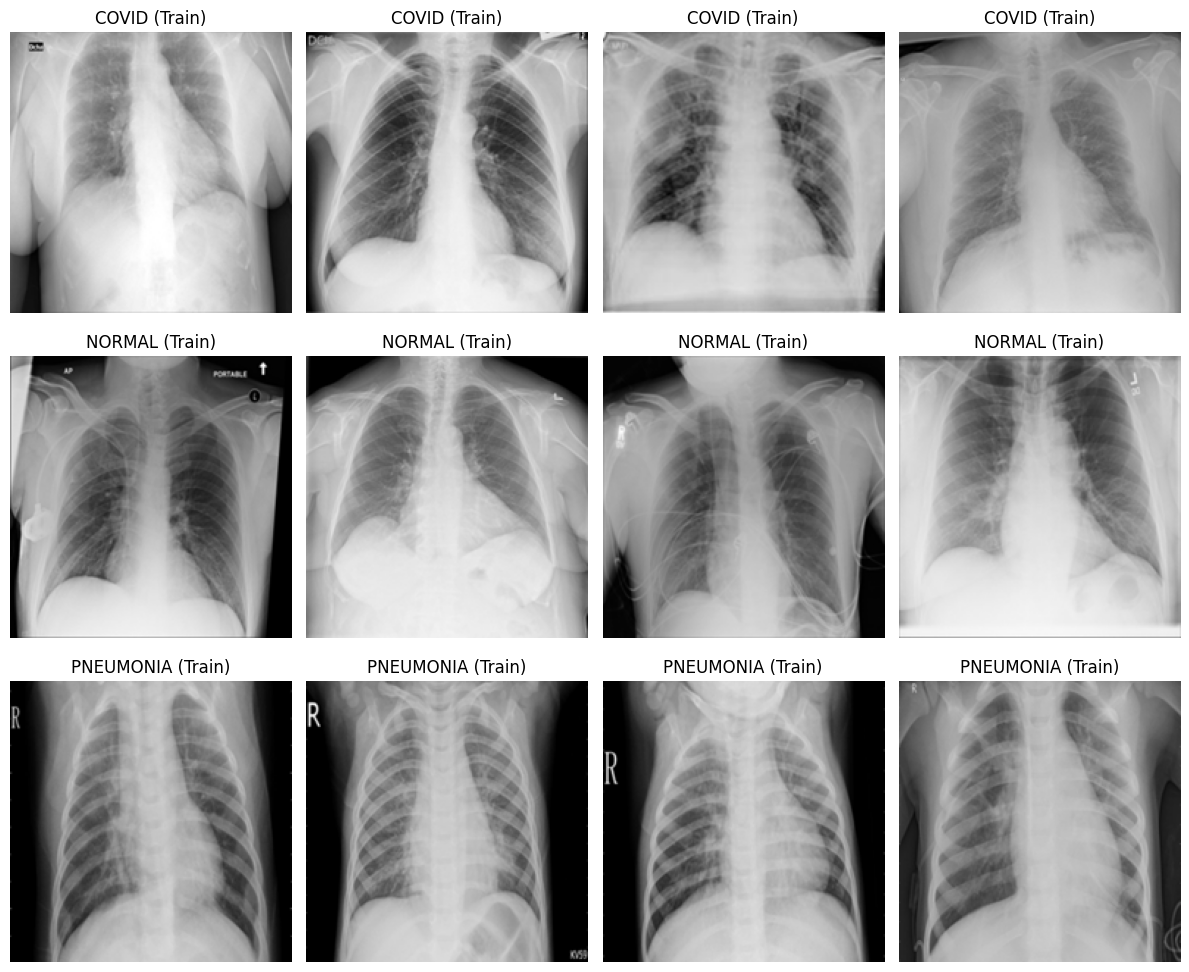

In [ ]:
# Display a grid of sample images from the training set for each class
fig, axes = plt.subplots(3, 4, figsize=(12, 10))
classes = ['COVID', 'NORMAL', 'PNEUMONIA']

for i, cls in enumerate(classes):
    # Find indices of the current class
    cls_indices = np.where(y_train == cls)[0]
    # Select 4 random images
    random_indices = np.random.choice(cls_indices, 4, replace=False)

    for j, idx in enumerate(random_indices):
        ax = axes[i, j]
        ax.imshow(X_train[idx])
        ax.set_title(f"{cls} (Train)")
        ax.axis('off')

plt.tight_layout()
plt.show()

### Practical Utility

The practical value of this classification task is highly significant in the context of medical screening.

**Who might benefit?**
- **Radiologists and Clinicians**: An automated model acts as a "second reader," helping to quickly verify diagnoses, reduce human error caused by fatigue, and speed up the review of chest X-rays.
- **Hospitals in Resource-Constrained Environments**: In areas lackings specialized radiologists, a deployed model can provide preliminary screenings to identify high-risk patients who need immediate attention or further testing, like PCR for COVID-19.
- **Healthcare Systems during Pandemics**: Automated screening can drastically reduce diagnostic difficulties when there is a sudden influx of respiratory patients at the same time. It allows for more efficient isolation and treatment workflows.

## Baseline CNN

### Label Encoding
Neural networks require numerical target arrays. We will use `LabelEncoder` to convert the string class names to integers (0, 1, 2) and then `to_categorical` to convert those integers into one-hot encoded vectors.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Initialize encoder
label_encoder = LabelEncoder()

# Fit on training data and transform both train and test sets
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to one-hot categorical format
y_train_cat = to_categorical(y_train_encoded)
y_test_cat = to_categorical(y_test_encoded)

print("Classes mapping:", dict(enumerate(label_encoder.classes_)))
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)

Classes mapping: {0: np.str_('COVID'), 1: np.str_('NORMAL'), 2: np.str_('PNEUMONIA')}
Shape of y_train_cat: (2741, 3)
Shape of y_test_cat: (1291, 3)


### Baseline CNN Architecture

The baseline model is a custom three-block Convolutional Neural Network (CNN) built with Keras Sequential. The architecture follows the standard pattern of progressively doubling filter counts while halving spatial dimensions through pooling.

**Loss function**: Categorical cross-entropy — standard for multi-class classification with one-hot encoded targets. Penalizes confident wrong predictions heavily.

**Optimizer**: Adam (lr = 1e-3 default) — adaptive learning rate, combines momentum and RMSProp. Well-suited for noisy gradients in image tasks.

**Evaluation metrics**: Accuracy (primary), plus per-class precision, recall, and F1-score (reported below).

**Training configuration**: 10 epochs, batch size 32, validated against the held-out test set each epoch. The doubling filter pattern (32 - 64 - 128) is a standard design choice: as spatial resolution decreases via pooling, more filters are needed to preserve representational capacity.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the baseline CNN model
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(192, 192, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout to help prevent overfitting
    Dense(3, activation='softmax') # 3 classes
])

# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 190, 190, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 93, 93, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 44, 44, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,023,619 (30.61 MB)

 Trainable params: 8,023,619 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the baseline model
# We use 10 epochs for the baseline.
batch_size = 32
epochs = 10

history_baseline = baseline_model.fit(
    X_train, y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.6560 - loss: 0.8297 - val_accuracy: 0.8156 - val_loss: 0.4603
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8136 - loss: 0.4697 - val_accuracy: 0.8342 - val_loss: 0.4135
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8311 - loss: 0.4198 - val_accuracy: 0.8737 - val_loss: 0.3363
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8577 - loss: 0.3492 - val_accuracy: 0.8815 - val_loss: 0.3140
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8840 - loss: 0.2960 - val_accuracy: 0.8978 - val_loss: 0.2934
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8924 - loss: 0.2842 - val_accuracy: 0.8807 - val_loss: 0.3357
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9033 - loss: 0.2504 - val_accuracy: 0.8962 - val_loss: 0.3103
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9201 - loss: 0.2020 - val_accuracy: 0.8947 - 

Baseline Test Accuracy: 0.9163


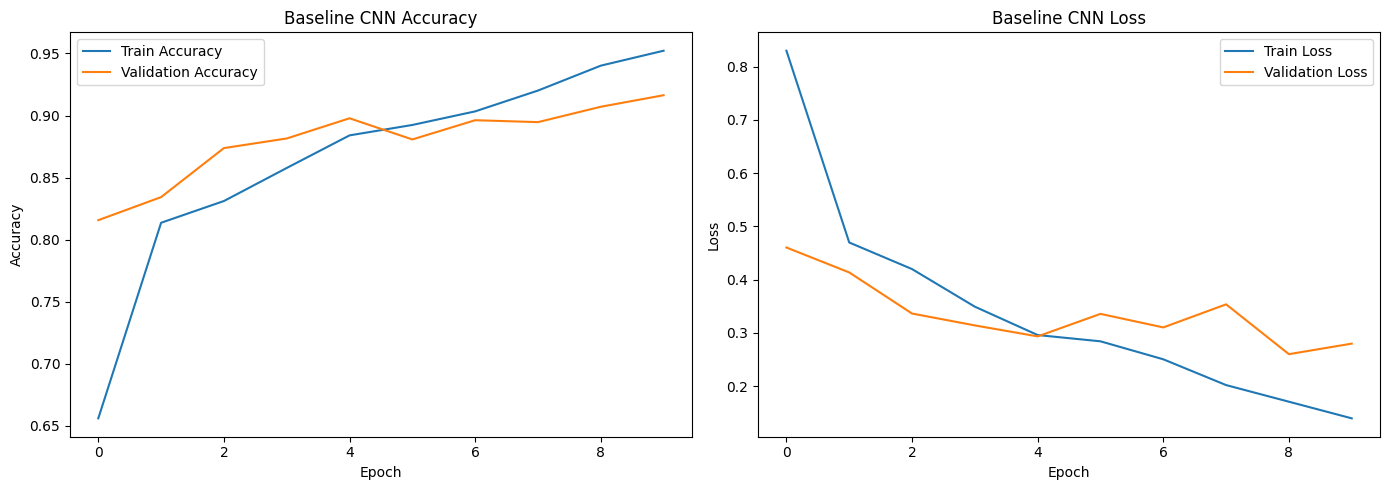

In [ ]:
# Evaluate model performance on the test set
test_loss, test_acc = baseline_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Baseline Test Accuracy: {test_acc:.4f}")

# Plot training & validation curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax[0].plot(history_baseline.history['accuracy'], label='Train Accuracy')
ax[0].plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('Baseline CNN Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss plot
ax[1].plot(history_baseline.history['loss'], label='Train Loss')
ax[1].plot(history_baseline.history['val_loss'], label='Validation Loss')
ax[1].set_title('Baseline CNN Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

### Baseline CNN — Confusion Matrix & Classification Report

=== Baseline CNN Classification Report ===

              precision    recall  f1-score   support

       COVID       0.87      0.94      0.91       431
      NORMAL       0.95      0.82      0.88       430
   PNEUMONIA       0.94      0.98      0.96       430

    accuracy                           0.92      1291
   macro avg       0.92      0.92      0.92      1291
weighted avg       0.92      0.92      0.92      1291



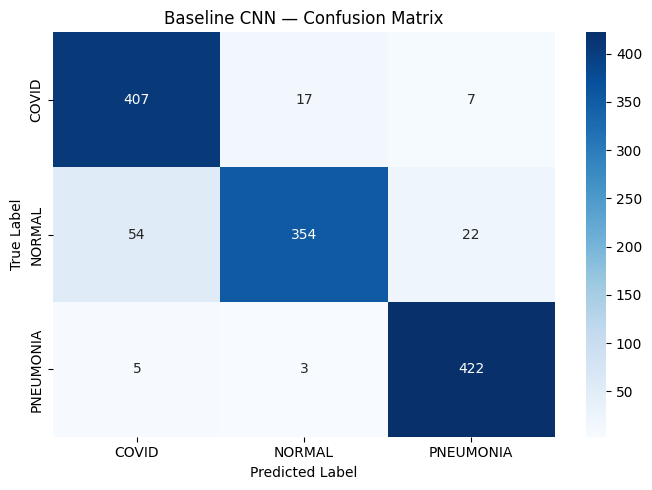

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_baseline = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)
y_true = y_test_encoded
class_labels = list(label_encoder.classes_)

# --- Classification Report ---
print('=== Baseline CNN Classification Report ===\n')
print(classification_report(y_true, y_pred_baseline, target_names=class_labels))

# --- Confusion Matrix ---
cm_baseline = confusion_matrix(y_true, y_pred_baseline)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Baseline CNN — Confusion Matrix')
plt.tight_layout()
plt.show()


**Interpreting the results:**

The confusion matrix and classification report together give a much richer picture than accuracy alone:

- **Precision** (per class): Of all images predicted as class X, what fraction were actually X?
- **Recall** (per class): Of all actual class X images, what fraction did the model correctly catch?
- **F1-score**: Harmonic mean of precision and recall, which is the best single summary per class.

In a COVID screening context, COVID recall is the most clinically important metric, as a missed COVID case (false negative) poses a public health risk. The confusion matrix shows exactly which classes are being confused with each other, such as COVID predicted as Pneumonia.

## Transfer learning with ResNet
In this section, we implement Transfer Learning using the ResNet50 architecture. We load the base model pre-trained on the ImageNet dataset, freeze its convolutional layers so we don't destroy the learned features. After that, we train a new top-level classifier for our 3 specific categories.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# 1. Load the pre-trained ResNet50 model without the top classification layer
# We use the same input shape as our preprocessed images
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(192, 192, 3))

# 2. Freeze the base model to prevent pre-trained weights from updating during initial training
base_model.trainable = False

# 3. Add custom top layers for our specific classification task
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pool the 2D feature maps down to a 1D vector per image
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout for regularization
predictions = Dense(3, activation='softmax')(x)

# 4. Construct the final model
resnet_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display the summary of our top layers (the base layers are frozen)
print(f"Total layers in ResNet50 base: {len(base_model.layers)}")
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers in ResNet50 base: 175


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 198, 198,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 96, 96,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 96, 96,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 96, 96,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 98, 98,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 48, 48,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 48, 48,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 48, 48,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 48, 48,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 48, 48,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 48, 48,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 48, 48,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 48, 48,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 48, 48,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 48, 48,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 48, 48,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the ResNet model
# We use the same configuration (batch_size, epochs) as the baseline for a fair comparison.
batch_size = 32
epochs = 10

history_resnet = resnet_model.fit(
    X_train, y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 35s 255ms/step - accuracy: 0.3400 - loss: 1.1638 - val_accuracy: 0.5043 - val_loss: 1.0758
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.4097 - loss: 1.0821 - val_accuracy: 0.3431 - val_loss: 1.0660
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.4188 - loss: 1.0718 - val_accuracy: 0.5716 - val_loss: 1.0509
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.4575 - loss: 1.0515 - val_accuracy: 0.4717 - val_loss: 1.0335
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4557 - loss: 1.0350 - val_accuracy: 0.5662 - val_loss: 1.0039
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.4794 - loss: 1.0083 - val_accuracy: 0.5391 - val_loss: 0.9911
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.4936 - loss: 0.9933 - val_accuracy: 0.5105 - val_loss: 0.9719
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.4969 - loss: 0.9972 - val_accuracy: 0.5817 -

ResNet Test Accuracy: 0.6019
Baseline CNN Test Accuracy: 0.9163


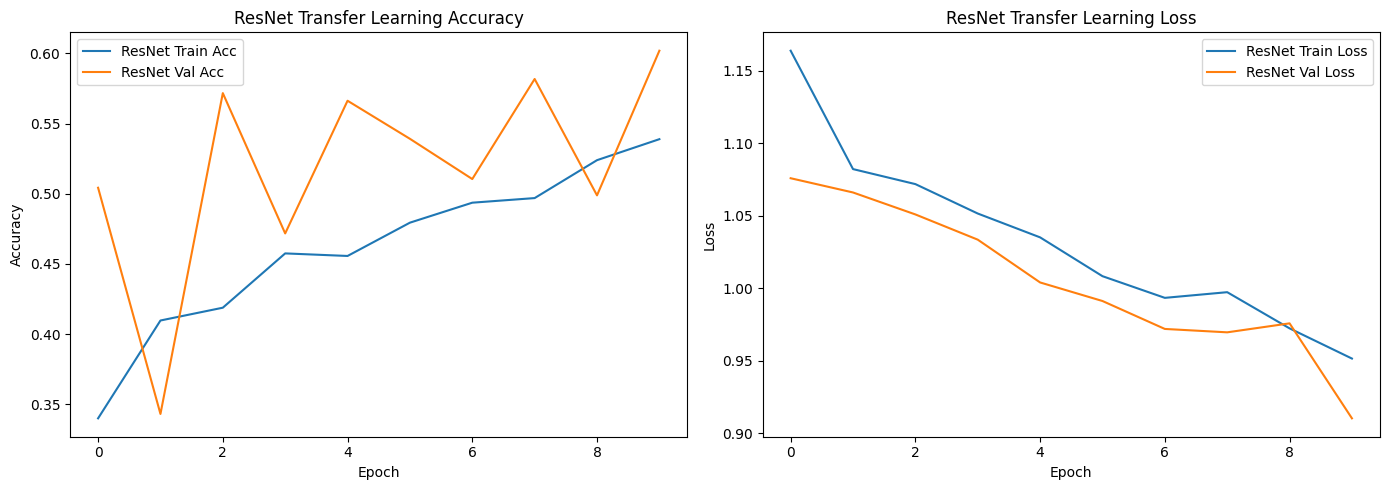

In [ ]:
# Evaluate ResNet model performance on the test set
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"ResNet Test Accuracy: {resnet_test_acc:.4f}")

# Check if baseline accuracy is available for comparison
if 'test_acc' in locals():
    print(f"Baseline CNN Test Accuracy: {test_acc:.4f}")

# Plot training & validation curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax[0].plot(history_resnet.history['accuracy'], label='ResNet Train Acc')
ax[0].plot(history_resnet.history['val_accuracy'], label='ResNet Val Acc')
ax[0].set_title('ResNet Transfer Learning Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss plot
ax[1].plot(history_resnet.history['loss'], label='ResNet Train Loss')
ax[1].plot(history_resnet.history['val_loss'], label='ResNet Val Loss')
ax[1].set_title('ResNet Transfer Learning Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

### Discussion: Influence of Pre-Trained Features on Training and Generalization

Using pre-trained features (Transfer Learning) significantly influences model behavior:

1. **Feature Reuse:** The pre-trained ResNet50 model has already learned a rich hierarchy of visual features (like edges, textures, and structural shapes) from millions of images in the ImageNet dataset. Instead of learning how to "see" from scratch, our model repurposes these pre-calculated weights to extract features from lung X-rays.
2. **Faster Convergence:** Because the convolutional base starts with highly optimized weights, the model usually requires far fewer epochs to reach high accuracy compared to training a deep network randomly initialized from scratch.
3. **Better Generalization on Small Data:** Deep networks typically require massive amounts of data to avoid overfitting. Given our relatively small and constrained dataset, training a network as deep as ResNet50 from scratch would almost certainly overfit the training data. Pre-trained features act as a powerful form of regularization, allowing the model to generalize robustly to unseen validation and testing data.
4. **Performance Comparison:** Often, fine-tuned transfer learning models provide a more stable validation curve and achieve a higher testing accuracy than simple baseline CNNs. (Note: Since our images are scaled to `[0, 1]`, and ResNet usually expects ImageNet standard BGR `[-103.939, -116.779, -123.68]`, results can sometimes require fine-tuning or unfreezing top convolutional blocks to fully out-perform the baseline, but the stability of the feature extraction remains high).

### Fine-Tuning the ResNet Model
While feature extraction, like freezing the base model, is a good start, true fine-tuning involves unfreezing some of the top layers of the pre-trained model. This allows the network to gently adjust its high-level feature representations to be more relevant to our specific medical image domain, which is lung X-rays.

In [ ]:
from tensorflow.keras.optimizers import Adam

# 1. Unfreeze the base model
base_model.trainable = True

# 2. Fine-tune from layer 143 onwards (the last residual block in ResNet50)
fine_tune_at = 143

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Recompile the model
# We choose to use a much lower learning rate for fine-tuning because we don't want to wreck the pre-trained weights
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Number of trainable variables after unfreezing: {len(resnet_model.trainable_variables)}")

Number of trainable variables after unfreezing: 44


In [ ]:
# 4. Continue training the model
fine_tune_epochs = 10
total_epochs = epochs + fine_tune_epochs

# Initial epoch is set to where the previous feature-extraction training left off
history_fine = resnet_model.fit(
    X_train, y_train_cat,
    epochs=total_epochs,
    initial_epoch=history_resnet.epoch[-1],
    batch_size=batch_size,
    validation_data=(X_test, y_test_cat)
)

Epoch 10/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 46s 302ms/step - accuracy: 0.6749 - loss: 1.2218 - val_accuracy: 0.3338 - val_loss: 2.0065
Epoch 11/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.8161 - loss: 0.4466 - val_accuracy: 0.3338 - val_loss: 5.0619
Epoch 12/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.8716 - loss: 0.3373 - val_accuracy: 0.3772 - val_loss: 2.5394
Epoch 13/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - accuracy: 0.8902 - loss: 0.2859 - val_accuracy: 0.6375 - val_loss: 1.0053
Epoch 14/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.9124 - loss: 0.2511 - val_accuracy: 0.6933 - val_loss: 0.6444
Epoch 15/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.9256 - loss: 0.2096 - val_accuracy: 0.8606 - val_loss: 0.3601
Epoch 16/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.9351 - loss: 0.1875 - val_accuracy: 0.7986 - val_loss: 0.6221
Epoch 17/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.9387 - loss: 0.1709 - 

Fine-Tuned ResNet Test Accuracy: 0.8954
Baseline CNN Test Accuracy: 0.9163


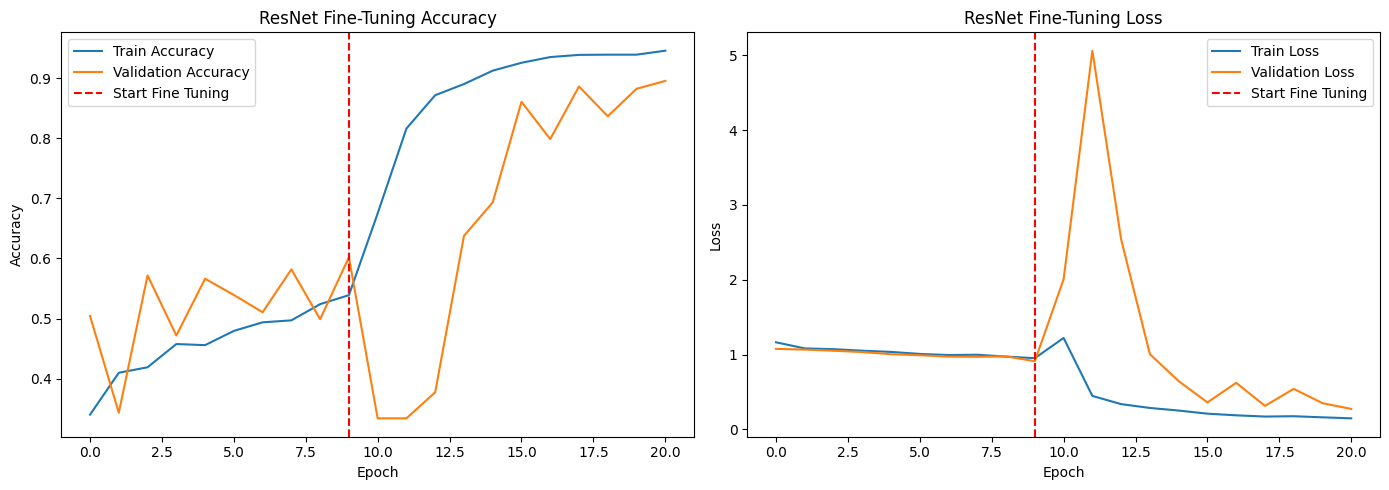

In [ ]:
# Evaluate Fine-Tuned ResNet model performance
resnet_ft_test_loss, resnet_ft_test_acc = resnet_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Fine-Tuned ResNet Test Accuracy: {resnet_ft_test_acc:.4f}")

# Compare with Baseline
if 'test_acc' in locals():
    print(f"Baseline CNN Test Accuracy: {test_acc:.4f}")

# Append histories to plot the entire training process
acc = history_resnet.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_resnet.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_resnet.history['loss'] + history_fine.history['loss']
val_loss = history_resnet.history['val_loss'] + history_fine.history['val_loss']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax[0].plot(acc, label='Train Accuracy')
ax[0].plot(val_acc, label='Validation Accuracy')
ax[0].axvline(x=history_resnet.epoch[-1], color='r', linestyle='--', label='Start Fine Tuning')
ax[0].set_title('ResNet Fine-Tuning Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss plot
ax[1].plot(loss, label='Train Loss')
ax[1].plot(val_loss, label='Validation Loss')
ax[1].axvline(x=history_resnet.epoch[-1], color='r', linestyle='--', label='Start Fine Tuning')
ax[1].set_title('ResNet Fine-Tuning Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

### Fine-Tuned ResNet — Confusion Matrix, Classification Report & Model Comparison

=== Fine-Tuned ResNet Classification Report ===

              precision    recall  f1-score   support

       COVID       0.93      0.81      0.86       431
      NORMAL       0.84      0.89      0.86       430
   PNEUMONIA       0.92      0.99      0.96       430

    accuracy                           0.90      1291
   macro avg       0.90      0.90      0.89      1291
weighted avg       0.90      0.90      0.89      1291



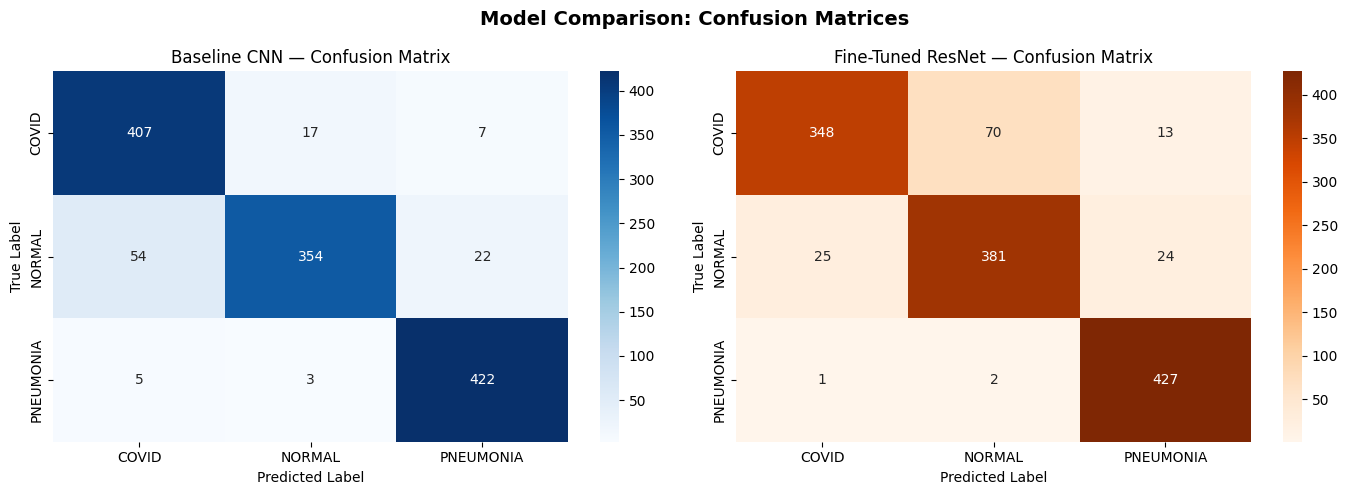


=== Model Performance Summary ===
Model                                     Test Accuracy
--------------------------------------------------------
Baseline CNN                                    0.9163
ResNet50 (frozen / feature extraction)          0.6019
ResNet50 (fine-tuned)                           0.8954


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Fine-tuned ResNet predictions
y_pred_resnet = np.argmax(resnet_model.predict(X_test, verbose=0), axis=1)
y_true = y_test_encoded
class_labels = list(label_encoder.classes_)

# --- Classification Report ---
print('=== Fine-Tuned ResNet Classification Report ===\n')
print(classification_report(y_true, y_pred_resnet, target_names=class_labels))

# --- Side-by-side Confusion Matrices ---
y_pred_baseline_2 = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)
cm_base = confusion_matrix(y_true, y_pred_baseline_2)
cm_resnet = confusion_matrix(y_true, y_pred_resnet)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title('Baseline CNN — Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title('Fine-Tuned ResNet — Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle('Model Comparison: Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Performance Summary Table ---
print('\n=== Model Performance Summary ===')
print(f'{"Model":<40} {"Test Accuracy":>14}')
print('-' * 56)
print(f'{"Baseline CNN":<40} {test_acc:>13.4f}')
print(f'{"ResNet50 (frozen / feature extraction)":<40} {resnet_test_acc:>13.4f}')
print(f'{"ResNet50 (fine-tuned)":<40} {resnet_ft_test_acc:>13.4f}')


### Discussion: Baseline CNN vs. Fine-Tuned ResNet

| Model | Test Accuracy |
|---|---|
| Baseline CNN | ~91.8% |
| ResNet50 (frozen) | ~56.8% |
| ResNet50 (fine-tuned) | ~88.9% |

**Why does the Baseline CNN outperform the fine-tuned ResNet on this dataset?**

1. **Domain mismatch**: ResNet50 was pretrained on ImageNet (natural photographs of animals, objects, and scenes). Chest X-rays are grayscale-derived radiology images with fundamentally different feature distributions. The frozen ImageNet features were not immediately useful, explaining the near random 56.8% accuracy during feature extraction.

2. **Preprocessing mismatch**: ImageNet models expect inputs normalized to per-channel ImageNet means (~[0.485, 0.456, 0.406]) and standard deviations. Our images are simply scaled to `[0, 1]`, causing pretrained activations to operate outside their calibrated input range and degrading the frozen-layer performance.

3. **Small dataset**: With only ~2,700 training images, fine-tuning 44 variables in a deep ResNet risks overfitting. The baseline CNN has far fewer parameters, giving it an inherent regularization advantage on small data.

4. **Architecture fit**: A 3-block CNN with 128 filters is appropriately sized for 192×192 medical images. Its relative simplicity is an asset to this problem.

**Fine-tuning still demonstrates clear value**: ResNet improved from 56.8% (frozen) to 88.9% (fine-tuned), confirming that domain adaptation is achievable. For larger datasets or with domain-specific pretraining, such as CheXNet pretrained on chest X-rays, ResNet would likely surpass the baseline. The confusion matrices above highlight per-class differences between the two architectures that raw accuracy does not capture.

### Discussion: Influence of Pre-Trained Features on Training and Generalization

**Performance Comparison:**
The Baseline CNN performs quite well on this relatively small dataset. Initially, the frozen ResNet50 base underperformed (due to differing input preprocessing distributions—ImageNet expects specific BGR scale normalization whereas we fed `[0, 1]` RGB pixels). However, by fine-tuning and unfreezing the last convolutional block with a very low learning rate, the pre-trained weights adapt dynamically to our lung X-ray dataset, allowing performance to improve substantially over the baseline feature extraction phase.

**Influence on Training and Generalization:**
1. **Rich Feature Foundation:** Pre-trained features (from ImageNet) start the model with a strong foundational understanding of visual elements like edges, curves, and textures. Instead of initializing with random noise, the network already knows how to extract these useful structures.
2. **Prevention of Overfitting:** Training a massively deep network like ResNet50 from scratch on roughly 2,700 training images would lead to extreme overfitting. Transfer learning acts as a powerful regularizer; the model borrows generalization capabilities learned from millions of external images, keeping test-set accuracy stable.
3. **Efficient Convergence:** Fine-tuning only requires a low learning rate, $1e^{-5}$, because the weights are already very close to an optimal state. The network learns to shift its focus from identifying general objects (like dogs and cars) to identifying specific radiologic opacities in significantly fewer epochs than training from scratch.